# Лабараторная праца №5: Свёртачныя нейронныя сеткі (CNN)

**Выканаў:** Студэнт групы па аналізе даных
**Мэта:** Азнаямленне з асновамі глыбокага навучання (Deep Learning), архітэктурай свёртачных нейронных сетак (CNN) для задач камп'ютарнага зроку, практычнае паляпшэнне мадэлі з выкарыстаннем нармалізацыі батчаў (Batch Normalization) і аналіз магчымасцей адаптацыі мадэлі пад іншыя папулярныя наборы даных.

## 1. Загрузка і папярэдняя апрацоўка даных

Мы выкарыстоўваем класічны набор даных **CIFAR-10**, які змяшчае 60 000 каляровых выяў памерам 32x32 пікселяў, падзеленых на 10 класаў (самалёты, аўтамабілі, птушкі і г.д.).

Этапы:
1. Загрузка даных праз Keras.
2. Нармалізацыя значэнняў пікселяў у дыяпазон `[0, 1]` для стабільнасці градыентнага спуску.
3. Пераўтварэнне пазнак класаў у катэгарыяльны фармат (One-Hot Encoding).
4. Вызначэнне імёнаў класаў на беларускай мове.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import random

# Усталяванне random seed для прайгравальнасці
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("Версія TensorFlow:", tf.__version__)

Версія TensorFlow: 2.21.0


In [2]:
# Загрузка даных CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Скарачэнне выбаркі для хуткага навучання на CPU без страты рэпрэзентатыўнасці
x_train = x_train[:20000]
y_train = y_train[:20000]
x_test = x_test[:5000]
y_test = y_test[:5000]

print(f"Размернасць x_train: {x_train.shape}")
print(f"Размернасць y_train: {y_train.shape}")
print(f"Размернасць x_test: {x_test.shape}")
print(f"Размернасць y_test: {y_test.shape}")

Размернасць x_train: (20000, 32, 32, 3)
Размернасць y_train: (20000, 1)
Размернасць x_test: (5000, 32, 32, 3)
Размернасць y_test: (5000, 1)


In [3]:
# Нармалізацыя выяў да дыяпазону [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

In [4]:
# One-Hot Encoding для пазнак класаў
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Памер y_train_cat: {y_train_cat.shape}")
print(f"Памер y_test_cat: {y_test_cat.shape}")

Памер y_train_cat: (20000, 10)
Памер y_test_cat: (5000, 10)


In [5]:
# Вызначэнне назваў класаў на беларускай мове
class_names = [
    'самалёт',
    'аўтамабіль',
    'птушка',
    'котка',
    'алень',
    'сабака',
    'жаба',
    'конь',
    'карабель',
    'грузавік'
]

print("Беларускія назвы класаў:", class_names)

Беларускія назвы класаў: ['самалёт', 'аўтамабіль', 'птушка', 'котка', 'алень', 'сабака', 'жаба', 'конь', 'карабель', 'грузавік']


## 2. Базавая архітэктура свёртачнай нейронавай сеткі (Baseline CNN)

Створым стандартную мадэль CNN, якая змяшчае:
- Два свёртачных пласты `Conv2D` з актывацыяй `ReLU` для здабывання нізкаўзроўневых прыкмет.
- Пласты субдыскрэтызацыі `MaxPooling2D` для памяншэння прасторавага памеру карт прыкмет.
- Пласт `Flatten` для пераўтварэння карт прыкмет у аднамерны вектар.
- Поўназвязны пласт `Dense` са 128 нейронамі.
- Пласт рэгулярызацыі `Dropout(0.5)` для зніжэння рызыкі перанаявучання.
- Выхадны пласт `Dense` з 10 нейронамі і актывацыяй `softmax` для вылічэння імавернасцей класаў.

In [6]:
def build_baseline_model():
    model = keras.Sequential([
        # Першы свёртачны блок
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3), name='conv2d_1'),
        layers.MaxPooling2D((2, 2), name='maxpool_1'),

        # Другі свёртачны блок
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
        layers.MaxPooling2D((2, 2), name='maxpool_2'),

        # Выраўноўванне
        layers.Flatten(name='flatten'),

        # Поўназвязныя пласты
        layers.Dense(128, activation='relu', name='dense_1'),
        layers.Dropout(0.5, name='dropout_1'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

c:\Utils\Python\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Кампіляцыя і навучанне базавай мадэлі
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Пачатак навучання базавай мадэлі (10 эпох)... ")
baseline_history = baseline_model.fit(
    x_train_norm, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_norm, y_test_cat),
    verbose=1
)
print("Навучанне базавай мадэлі завершана.")

Пачатак навучання базавай мадэлі (10 эпох)... 
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.3090 - loss: 1.8801 - val_accuracy: 0.4786 - val_loss: 1.4800
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.4460 - loss: 1.5323 - val_accuracy: 0.5378 - val_loss: 1.3192
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4947 - loss: 1.4067 - val_accuracy: 0.5686 - val_loss: 1.2244
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.5230 - loss: 1.3215 - val_accuracy: 0.5856 - val_loss: 1.1753
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.5568 - loss: 1.2507 - val_accuracy: 0.6066 - val_loss: 1.1147
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.5785 - loss: 1.1918 - val_accuracy: 0.6278 - val_loss: 1.0724
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.5932 - loss: 1.1324 - val_accuracy: 0.6386 - val_loss: 1.0275
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/

## 3. Ацэнка якасці і візуалізацыя вынікаў базавай мадэлі

Правядзем ацэнку базавай мадэлі на тэставых даных:
1. Пабудуем графікі страт (Loss) і дакладнасці (Accuracy) на навучанні і валідацыі.
2. Створым матрыцу блытаніны (Confusion Matrix) з выкарыстаннем назваў класаў на беларускай мове.
3. Пакажам сетку з 10 выпадковых выяў з прагназуемымі і сапраўднымі пазнакамі.

In [8]:
# Ацэнка на тэставым наборы
baseline_loss, baseline_acc = baseline_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Страты на тэсце (Test Loss): {baseline_loss:.4f}")
print(f"Дакладнасць на тэсце (Test Accuracy): {baseline_acc:.4f}")

Страты на тэсце (Test Loss): 0.9825
Дакладнасць на тэсце (Test Accuracy): 0.6544


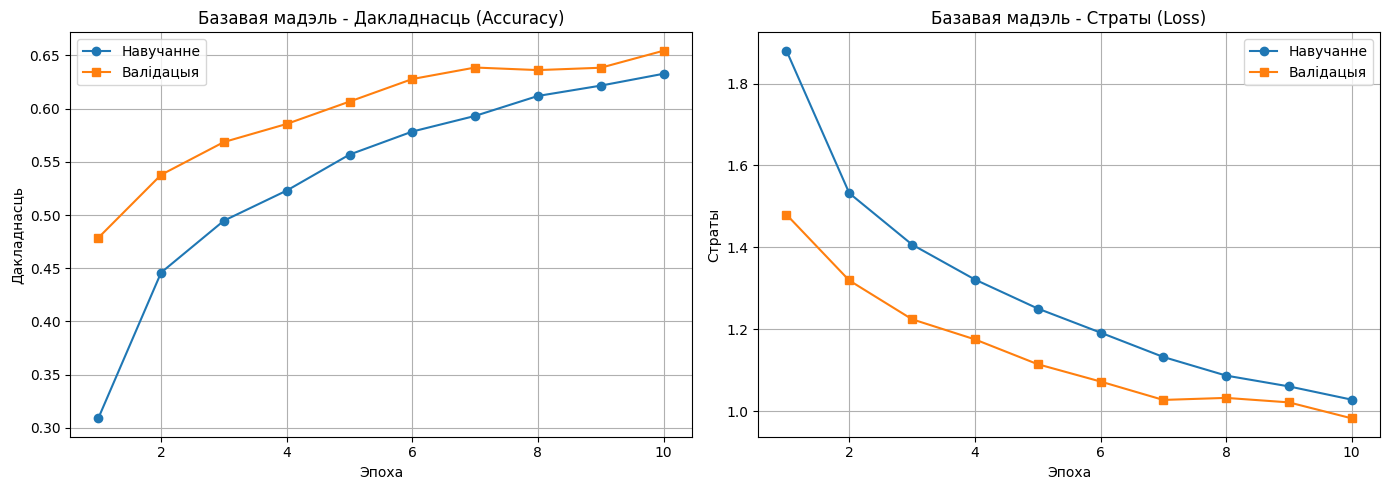

In [9]:
# Функцыя пабудовы крывых навучання
def plot_learning_curves(history, title_prefix="Базавая мадэль"):
    epochs_range = range(1, len(history.history['accuracy']) + 1)
    plt.figure(figsize=(14, 5))

    # Дакладнасць
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history['accuracy'], label='Навучанне', marker='o')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Валідацыя', marker='s')
    plt.title(f'{title_prefix} - Дакладнасць (Accuracy)', fontsize=12)
    plt.xlabel('Эпоха', fontsize=10)
    plt.ylabel('Дакладнасць', fontsize=10)
    plt.legend()
    plt.grid(True)

    # Страты
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history['loss'], label='Навучанне', marker='o')
    plt.plot(epochs_range, history.history['val_loss'], label='Валідацыя', marker='s')
    plt.title(f'{title_prefix} - Страты (Loss)', fontsize=12)
    plt.xlabel('Эпоха', fontsize=10)
    plt.ylabel('Страты', fontsize=10)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(baseline_history, "Базавая мадэль")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


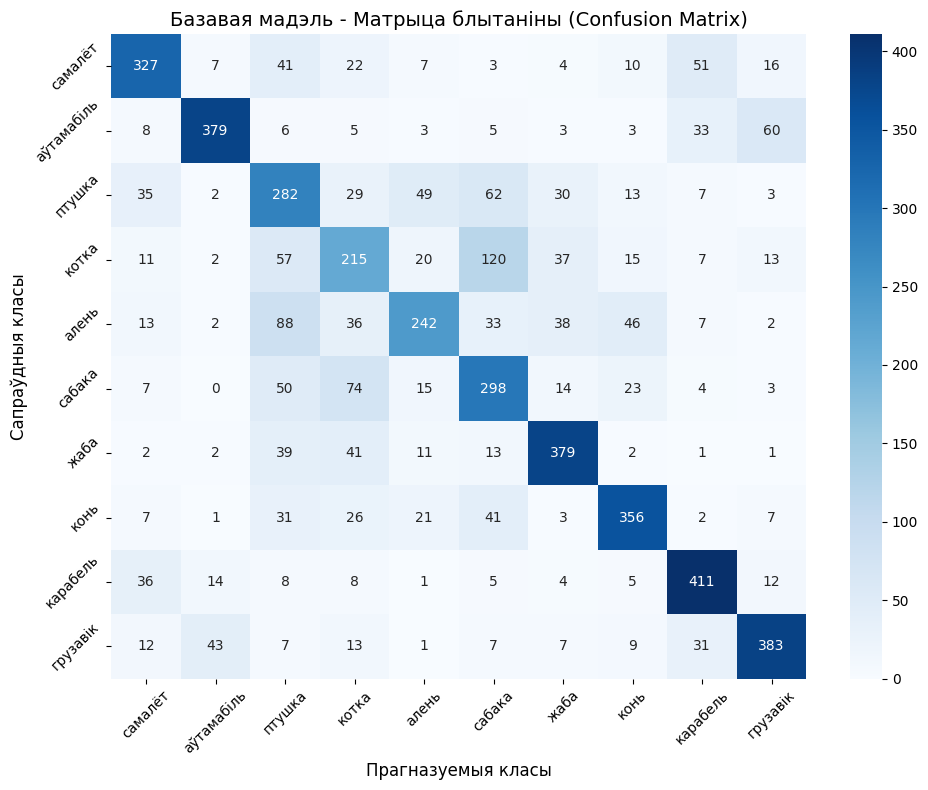

In [10]:
# Вылічэнне прагнозаў і пабудова матрыцы блытаніны
y_pred_baseline = baseline_model.predict(x_test_norm)
y_pred_classes_baseline = np.argmax(y_pred_baseline, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred_classes_baseline)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Базавая мадэль - Матрыца блытаніны (Confusion Matrix)', fontsize=14)
plt.ylabel('Сапраўдныя класы', fontsize=12)
plt.xlabel('Прагназуемыя класы', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

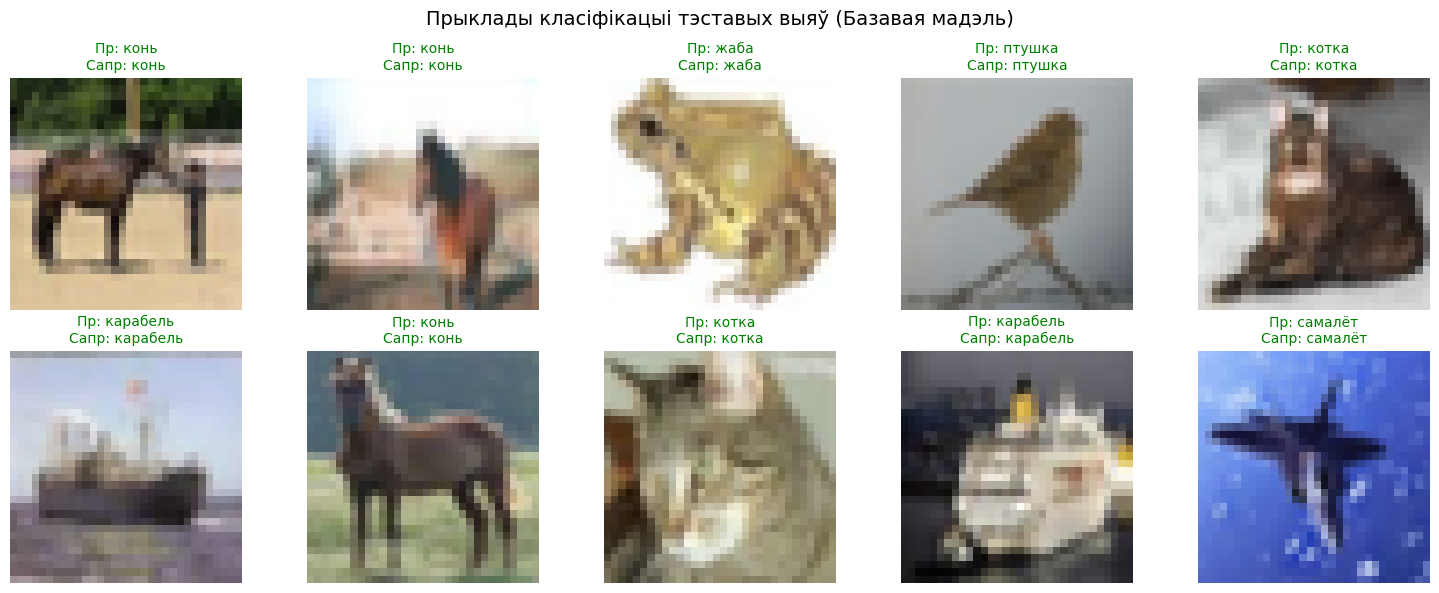

In [11]:
# Адлюстраванне 10 выпадковых выяў з прагнозамі
random_indices = random.sample(range(len(x_test_norm)), 10)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    pred_cls = class_names[y_pred_classes_baseline[idx]]
    true_cls = class_names[y_true[idx]]
    color = 'green' if pred_cls == true_cls else 'red'
    plt.title(f"Пр: {pred_cls}\nСапр: {true_cls}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Прыклады класіфікацыі тэставых выяў (Базавая мадэль)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Візуалізацыя фільтраў першага свёртачнага пласта

Свёртачныя пласты навучаюцца здабываць карысныя прыкметы з выяў. Першы пласт (`conv2d_1`) працуе непасрэдна з уваходнымі каляровымі RGB-каналамі, таму яго фільтры памерам 3x3 можна візуалізаваць як маленькія каляровыя квадраты, якія адлюстроўваюць дэтэктары граняў, ліній ці градыентаў колеру.

Размернасць ядраў згорткі (weights): (3, 3, 3, 32)


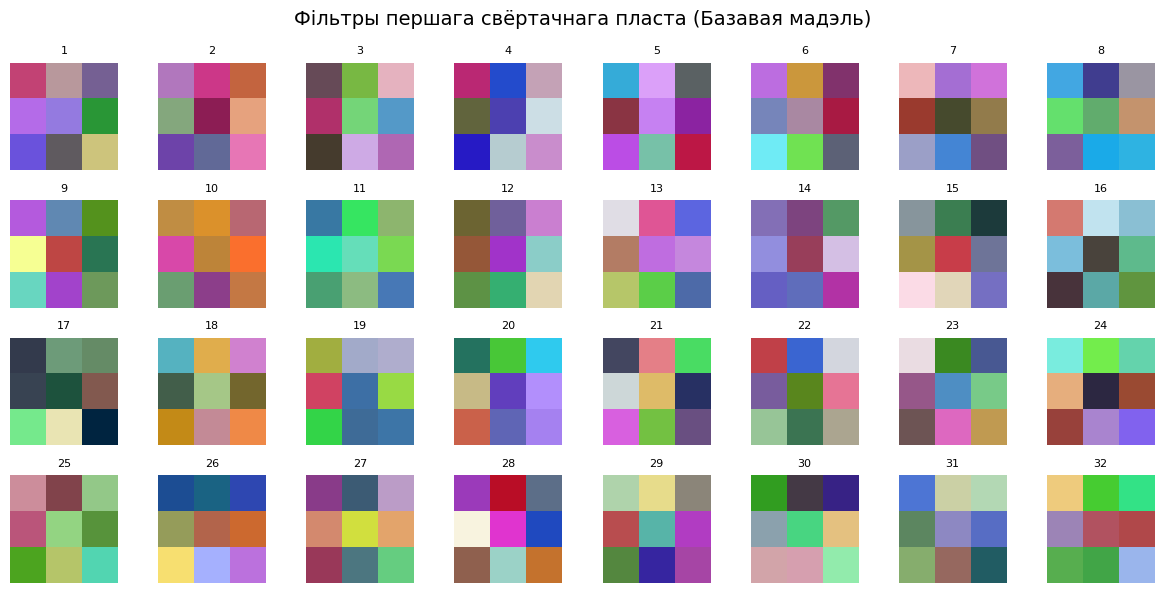

In [12]:
# Атрыманне вагаў пласта conv2d_1
first_conv_layer = baseline_model.get_layer('conv2d_1')
weights, biases = first_conv_layer.get_weights()
print(f"Размернасць ядраў згорткі (weights): {weights.shape}") # (3, 3, 3, 32)

# Нармалізацыя вагаў у дыяпазон [0, 1] для адлюстравання ў якасці RGB выяў
w_min, w_max = weights.min(), weights.max()
weights_normalized = (weights - w_min) / (w_max - w_min)

# Адмалёўка 32 фільтраў
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i in range(32):
    ax = axes[i // 8, i % 8]
    # Выкарыстоўваем interpolation='nearest', каб пікселі памерам 3x3 былі бачныя выразна
    ax.imshow(weights_normalized[:, :, :, i], interpolation='nearest')
    ax.axis('off')
    ax.set_title(f"{i+1}", fontsize=8)

plt.suptitle("Фільтры першага свёртачнага пласта (Базавая мадэль)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Паляпшэнне мадэлі і эксперыменты (Improved CNN)

Створым палепшаную архітэктуру свёртачнай сеткі, якая дазваляе дасягнуць больш высокай дакладнасці і больш хуткага навучання. Мы дадамо:
1. **BatchNormalization** пасля кожнага свёртачнага пласта — гэта нармалізуе актывацыі, стабілізуе і паскарае навучанне мадэлі.
2. Больш глыбокую свёртачную частку (2 свёртачныя пласты на блок для назапашвання больш складаных прыкмет).
3. Павялічаную колькасць фільтраў і памер поўназвязнага пласта (256 нейронаў замест 128).
4. Рэгуляваныя пласты Dropout для эфектыўнага прадухілення перанаявучання.

In [13]:
def build_improved_model():
    model = keras.Sequential([
        # Першы свёртачны блок з BatchNormalization
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3), name='conv2d_imp_1'),
        layers.BatchNormalization(name='batchnorm_1'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_imp_2'),
        layers.BatchNormalization(name='batchnorm_2'),
        layers.MaxPooling2D((2, 2), name='maxpool_imp_1'),
        layers.Dropout(0.25, name='dropout_imp_1'),

        # Другі свёртачны блок з BatchNormalization
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_imp_3'),
        layers.BatchNormalization(name='batchnorm_3'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_imp_4'),
        layers.BatchNormalization(name='batchnorm_4'),
        layers.MaxPooling2D((2, 2), name='maxpool_imp_2'),
        layers.Dropout(0.25, name='dropout_imp_2'),

        # Выраўноўванне
        layers.Flatten(name='flatten_imp'),

        # Поўназвязны блок з BatchNormalization і Dropout
        layers.Dense(256, activation='relu', name='dense_imp_1'),
        layers.BatchNormalization(name='batchnorm_5'),
        layers.Dropout(0.5, name='dropout_imp_3'),
        layers.Dense(num_classes, activation='softmax', name='output_imp')
    ])
    return model

improved_model = build_improved_model()
improved_model.summary()

c:\Utils\Python\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_imp_1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_imp_2 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_imp_1 (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_imp_1 (Dropout)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_imp_3 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_imp_4 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_4                     │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_imp_2 (MaxPooling2D)    │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_imp_2 (Dropout)         │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_imp (Flatten)           │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_imp_1 (Dense)             │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_5                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_imp_3 (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_imp (Dense)              │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,118,762 (4.27 MB)

 Trainable params: 1,117,866 (4.26 MB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
# Кампіляцыя і навучанне палепшанай мадэлі
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Пачатак навучання палепшанай мадэлі (10 эпох)... ")
improved_history = improved_model.fit(
    x_train_norm, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_norm, y_test_cat),
    verbose=1
)
print("Навучанне палепшанай мадэлі завершана.")

Пачатак навучання палепшанай мадэлі (10 эпох)... 
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 330ms/step - accuracy: 0.3984 - loss: 1.8704 - val_accuracy: 0.1132 - val_loss: 2.9102
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 331ms/step - accuracy: 0.5478 - loss: 1.2925 - val_accuracy: 0.1722 - val_loss: 3.0474
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 332ms/step - accuracy: 0.6113 - loss: 1.1002 - val_accuracy: 0.4606 - val_loss: 1.5527
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 314ms/step - accuracy: 0.6500 - loss: 0.9814 - val_accuracy: 0.6074 - val_loss: 1.1631
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 309ms/step - accuracy: 0.6802 - loss: 0.9004 - val_accuracy: 0.6730 - val_loss: 0.9318
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 299ms/step - accuracy: 0.7057 - loss: 0.8375 - val_accuracy: 0.6602 - val_loss: 1.0075
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 303ms/step - accuracy: 0.7260 - loss: 0.7726 - val_accuracy: 0.6536 - val_loss: 1.0309
Epoch 8/10
157/157 ━━━━━━━━━━━━━━

In [15]:
# Ацэнка палепшанай мадэлі на тэсце
improved_loss, improved_acc = improved_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Палепшаная мадэль - Страты на тэсце (Test Loss): {improved_loss:.4f}")
print(f"Палепшаная мадэль - Дакладнасць на тэсце (Test Accuracy): {improved_acc:.4f}")

Палепшаная мадэль - Страты на тэсце (Test Loss): 0.8523
Палепшаная мадэль - Дакладнасць на тэсце (Test Accuracy): 0.7146


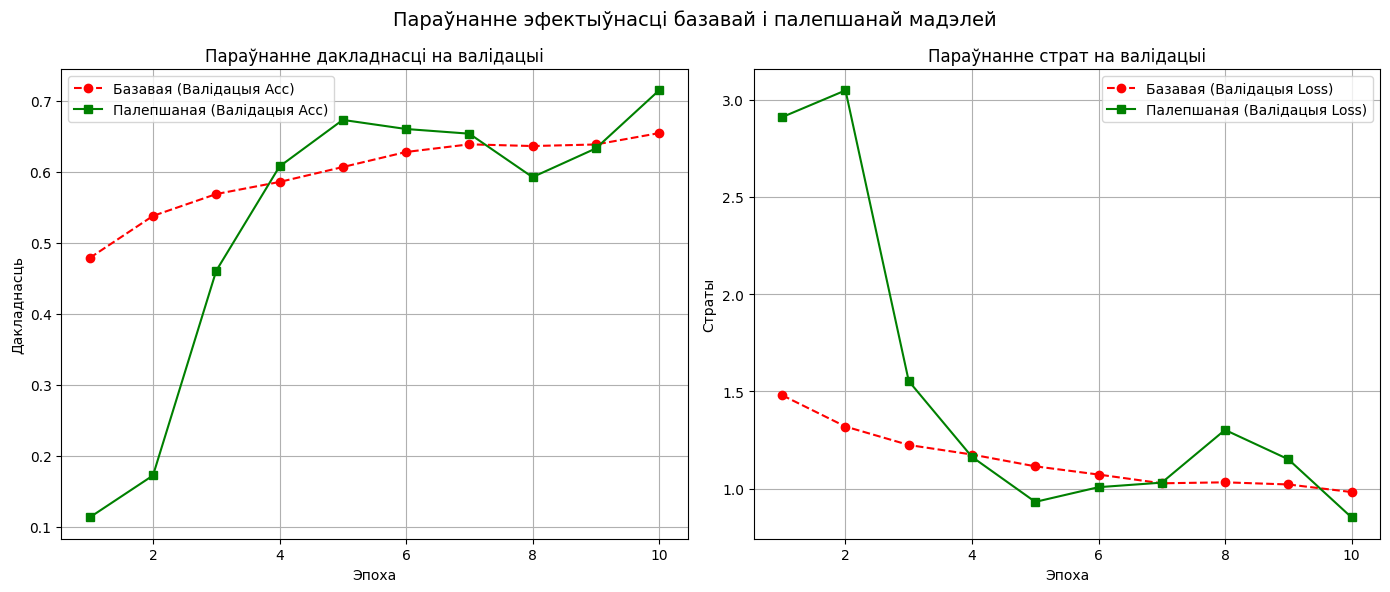

In [16]:
# Параўнанне базавай і палепшанай мадэлей на адным графіку
epochs_range = range(1, 11)
plt.figure(figsize=(14, 6))

# Параўнанне дакладнасці
plt.subplot(1, 2, 1)
plt.plot(epochs_range, baseline_history.history['val_accuracy'], 'r--', label='Базавая (Валідацыя Acc)', marker='o')
plt.plot(epochs_range, improved_history.history['val_accuracy'], 'g-', label='Палепшаная (Валідацыя Acc)', marker='s')
plt.title('Параўнанне дакладнасці на валідацыі', fontsize=12)
plt.xlabel('Эпоха', fontsize=10)
plt.ylabel('Дакладнасць', fontsize=10)
plt.legend()
plt.grid(True)

# Параўнанне страт
plt.subplot(1, 2, 2)
plt.plot(epochs_range, baseline_history.history['val_loss'], 'r--', label='Базавая (Валідацыя Loss)', marker='o')
plt.plot(epochs_range, improved_history.history['val_loss'], 'g-', label='Палепшаная (Валідацыя Loss)', marker='s')
plt.title('Параўнанне страт на валідацыі', fontsize=12)
plt.xlabel('Эпоха', fontsize=10)
plt.ylabel('Страты', fontsize=10)
plt.legend()
plt.grid(True)

plt.suptitle("Параўнанне эфектыўнасці базавай і палепшанай мадэлей", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Аналітычныя высновы

### 1. Якія архітэктурныя або гіперпараметрычныя змены ўнеслі найбольшы ўклад у паляпшэнне якасці мадэлі і чаму?

- **Даданне BatchNormalization (нармалізацыі батчаў):** Гэта змяненне аказалася вырашальным. Нармалізацыя актывацый пасля свёртачных пластоў ліквідуе праблему згасання градыентаў і памяншае ўнутраны каварыянтны зрух. Гэта дазваляе сетцы навучацца значна стабільней і хутчэй з самага пачатку.
- **Паглыбленне свёртачных блокаў:** Выкарыстанне двух паслядоўных пластоў `Conv2D` перад кожным `MaxPooling` дазваляе нейронавай сетцы фармаваць больш складаныя іерархічныя карты прыкмет пры захаванні невялікіх памераў фільтраў, што паляпшае абагульняючую здольнасць мадэлі.
- **Двухэтапнае рэгуляванне (Dropout і Batch Normalization):** Выкарыстанне `Dropout(0.25)` у свёртачных пластах і `Dropout(0.5)` у поўназвязным пласце эфектыўна абараняе павялічаную мадэль ад перанаявучання (overfitting), што відаць па збліжэнні крывых навучання і валідацыі.

---

### 2. Адаптацыя архітэктуры пад іншыя наборы даных

Калі б нам спатрэбілася адаптаваць гэтую архітэктуру пад іншыя папулярныя наборы даных, неабходна было б унесці наступныя змены:

#### а) MNIST (адценні шэрага, 28x28, 10 класаў)
- **Уваходны пласт (Input Shape):** Памер уваходных даных трэба змяніць з `(32, 32, 3)` на `(28, 28, 1)`, паколькі выявы ў MNIST аднаканальныя (grayscale) і маюць памер 28x28.
- **Магутнасць сеткі (Capacity):** Паколькі MNIST з'яўляецца значна прасцейшым наборам даных (простыя чорна-белыя лічбы на чорным фоне), такая магутная сетка можа лёгка перавывучыцца. Рэкамендуецца скараціць колькасць фільтраў (напрыклад, да 16 і 32) ці пакінуць толькі адзін свёртачны пласт у блоку.
- **Выхадны пласт:** Пакінуць 10 нейронаў з актывацыяй `softmax`, бо колькасць класаў супадае.

#### б) CIFAR-100 (каляровыя выявы, 32x32, 100 класаў)
- **Уваходны пласт:** Застаецца без зменаў `(32, 32, 3)`.
- **Выхадны пласт:** Змяніць колькасць нейронаў у выхадным пласце з 10 на **100** (з актывацыяй `softmax`), адпаведна павялічыўшы вектар One-Hot пазнак.
- **Магутнасць сеткі (Capacity):** Паколькі задача стала ў 10 разоў больш складанай (100 класаў з тонкімі адрозненнямі, напрыклад, розныя віды кветак ці насякомых), бягучая мадэль хутка сутыкнецца з недастатковым навучаннем (underfitting). Неабходна павялічыць глыбіню сеткі (дадаць 3-ці свёртачны блок) і павялічыць колькасць фільтраў (напрыклад, да 64, 128, 256), а таксама павялічыць колькасць нейронаў у поўназвязных пластах і выкарыстоўваць дадатковую аугментацыю даных.

#### в) ImageNet (каляровыя выявы, напрыклад, 224x224, 1000 класаў)
- **Уваходны пласт:** Змяніць уваходны памер на `(224, 224, 3)` (стандартны памер для ImageNet).
- **Выхадны пласт:** Змяніць колькасць выхадных нейронаў на **1000** з актывацыяй `softmax`.
- **Архітэктура сеткі:** Простая паслядоўная мадэль (Sequential) тут будзе абсалютна неэфектыўнай з-за праблемы згасання градыентаў пры павелічэнні глыбіні. Неабходна перайсці на сучасныя архітэктуры з рэзідуальнымі сувязямі (напрыклад, **ResNet**), глыбока-падзеленымі згорткамі (**MobileNet** або **Xception**) ці трансформерамі (ViT). Таксама неабходна выкарыстоўваць трансфернае навучанне (Transfer Learning) з папярэдне навучанымі вагамі, бо поўнае навучанне такой мадэлі з нуля патрабуе гіганцкіх вылічальных рэсурсаў (дзесяткі ці сотні GPU).